**Methods tested:**
1. No Sampling
2. Random Oversampling
3. SMOTE
4. ADASYN
5. BorderlineSMOTE
6. KMeans-SMOTE
7. SMOTE-ENN (Hybrid)
8. CTGAN

## Step 1: Install Libraries

In [ ]:
!pip install imbalanced-learn xgboost shap -q
!pip install ctgan -q

## Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score,
    precision_score, f1_score
)

from xgboost import XGBClassifier

from imblearn.over_sampling import (
    SMOTE,
    ADASYN,
    BorderlineSMOTE,
    KMeansSMOTE,
    RandomOverSampler
)
from imblearn.combine import SMOTEENN

from ctgan import CTGAN

## Step 3: Load Dataset from Kaggle

In [ ]:
!pip install kaggle -q
import json, os

kaggle_username  = ".env"
kaggle_api_token = ".env"

kaggle_auth_json = {
    "username": kaggle_username,
    "key": kaggle_api_token
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_auth_json, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d blastchar/telco-customer-churn -q
!unzip -q -o telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors


## Step 4: Data Cleaning

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df[df['tenure'] != 0].copy()

df = df.drop('customerID', axis=1)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)

print(f'Dataset shape after cleaning:  {df.shape}')
print(f'Encoded dataset shape:         {df_encoded.shape}')
print(f'\nClass distribution:')
print(f'  Stayed:  {(df["Churn"]==0).sum()} ({(df["Churn"]==0).mean()*100:.1f}%)')
print(f'  Churned: {(df["Churn"]==1).sum()} ({(df["Churn"]==1).mean()*100:.1f}%)')
print(f'  Ratio:   1:{round((df["Churn"]==0).sum()/(df["Churn"]==1).sum(),2)}')

Dataset shape after cleaning:  (7032, 20)
Encoded dataset shape:         (7032, 31)

Class distribution:
  Stayed:  5163 (73.4%)
  Churned: 1869 (26.6%)
  Ratio:   1:2.76


## Step 5: Train-Test Split
*(70-30 stratified split)*

In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'\nNote: SMOTE/sampling applied to training data ONLY.')
print(f'Test set remains original and untouched for fair comparison.')

Training set: (4922, 30)
Test set:     (2110, 30)

Note: SMOTE/sampling applied to training data ONLY.
Test set remains original and untouched for fair comparison.


## Step 6: Define XGBoost Model

In [ ]:
def get_xgb_model():
    return XGBClassifier(
        n_estimators  = 1000,
        max_depth     = 3,
        learning_rate = 0.01,
        eval_metric   = 'logloss',
        random_state  = 42,
        verbosity     = 0
    )

print('XGBoost template ready.')

XGBoost template ready.


## Step 7: CTGAN - Generate Synthetic Churners

CTGAN is trained separately before the main comparison loop.
It learns the distribution of real churners and generates new realistic ones.

In [ ]:
print('Training CTGAN on churner data...')
print('='*50)

train_df = X_train.copy()
train_df['Churn'] = y_train.values

churner_rows    = train_df[train_df['Churn'] == 1].drop('Churn', axis=1)
non_churner_rows = train_df[train_df['Churn'] == 0].drop('Churn', axis=1)

n_to_generate = len(non_churner_rows) - len(churner_rows)
print(f'Real churners in training:     {len(churner_rows)}')
print(f'Non-churners in training:      {len(non_churner_rows)}')
print(f'Synthetic churners to generate:{n_to_generate}')

ctgan = CTGAN(epochs=100, verbose=False)
ctgan.fit(churner_rows)

synthetic_churners = ctgan.sample(n_to_generate)
synthetic_churners = synthetic_churners[X_train.columns]

X_train_ctgan = pd.concat([
    X_train,
    synthetic_churners
], ignore_index=True)

y_train_ctgan = pd.concat([
    y_train,
    pd.Series([1] * n_to_generate)
], ignore_index=True)

print(f'\nCTGAN training complete!')
print(f'Balanced training set size: {len(X_train_ctgan)}')
print(f'Churners:     {(y_train_ctgan==1).sum()}')
print(f'Non-churners: {(y_train_ctgan==0).sum()}')

Training CTGAN on churner data...
Real churners in training:     1308
Non-churners in training:      3614
Synthetic churners to generate:2306

CTGAN training complete!
Balanced training set size: 7228
Churners:     3614
Non-churners: 3614


## Step 8: Run All 8 Methods and Collect Results

Each method trains XGBoost on differently balanced training data,
then evaluates on the **same original test set** for fair comparison.

In [ ]:
techniques = {
    '1. No Sampling': ('sampler', None),
    '2. Random Oversampling':    ('sampler', RandomOverSampler(random_state=42)),
    '3. SMOTE':                  ('sampler', SMOTE(random_state=42)),
    '4. ADASYN':                 ('sampler', ADASYN(random_state=42)),
    '5. BorderlineSMOTE':        ('sampler', BorderlineSMOTE(random_state=42)),
    '6. KMeans-SMOTE':           ('sampler', KMeansSMOTE(random_state=42)),
    '7. SMOTE-ENN (Hybrid)':     ('sampler', SMOTEENN(random_state=42)),
    '8. CTGAN':       ('precomputed', (X_train_ctgan, y_train_ctgan)),
}

results = []

for name, (mode, config) in techniques.items():
    print(f'Running {name}...')

    try:
        if mode == 'precomputed':
            X_res, y_res = config
        elif config is None:
            X_res, y_res = X_train.copy(), y_train.copy()
        else:
            X_res, y_res = config.fit_resample(X_train, y_train)

        model = get_xgb_model()
        model.fit(X_res, y_res)

        y_pred = model.predict(X_test)

        result = {
            'Method':            name,
            'Training Samples':  len(X_res),
            'Accuracy (%)':      round(accuracy_score(y_test, y_pred)  * 100, 2),
            'Precision (%)':     round(precision_score(y_test, y_pred) * 100, 2),
            'Recall (%)':        round(recall_score(y_test, y_pred)    * 100, 2),
            'F1-Score (%)':      round(f1_score(y_test, y_pred)        * 100, 2),
        }
        results.append(result)
        print(f'  Accuracy: {result["Accuracy (%)"]:.2f}% | '
              f'Recall: {result["Recall (%)"]:.2f}% | '
              f'F1: {result["F1-Score (%)"]:.2f}%')

    except Exception as e:
        print(f'  ERROR: {e}')
        results.append({
            'Method': name, 'Training Samples': 0,
            'Accuracy (%)': 0, 'Precision (%)': 0,
            'Recall (%)': 0, 'F1-Score (%)': 0
        })

print('\nAll methods complete!')

Running 1. No Sampling...
  Accuracy: 79.10% | Recall: 50.27% | F1: 56.12%
Running 2. Random Oversampling...
  Accuracy: 74.08% | Recall: 81.64% | F1: 62.61%
Running 3. SMOTE...
  Accuracy: 77.30% | Recall: 68.09% | F1: 61.46%
Running 4. ADASYN...
  Accuracy: 77.35% | Recall: 71.12% | F1: 62.54%
Running 5. BorderlineSMOTE...
  Accuracy: 76.40% | Recall: 70.94% | F1: 61.51%
Running 6. KMeans-SMOTE...
  ERROR: No clusters found with sufficient samples of class 1. Try lowering the cluster_balance_threshold or increasing the number of clusters.
Running 7. SMOTE-ENN (Hybrid)...
  Accuracy: 74.79% | Recall: 74.69% | F1: 61.17%
Running 8. CTGAN...
  Accuracy: 80.00% | Recall: 50.62% | F1: 57.37%

All methods complete!


## Step 9: Print Full Comparison Table

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[results_df['Accuracy (%)'] > 0].reset_index(drop=True)

print('=' * 95)
print(results_df.to_string(index=False))
print('=' * 95)

best_recall   = results_df.loc[results_df['Recall (%)'].idxmax()]
best_f1       = results_df.loc[results_df['F1-Score (%)'].idxmax()]
best_accuracy = results_df.loc[results_df['Accuracy (%)'].idxmax()]
baseline      = results_df[results_df['Method'].str.contains('No Sampling')].iloc[0]

print(f'\nBEST RECALL:   {best_recall["Method"]} -> {best_recall["Recall (%)"]:.2f}%')
print(f'BEST F1-SCORE: {best_f1["Method"]} -> {best_f1["F1-Score (%)"]:.2f}%')
print(f'BEST ACCURACY: {best_accuracy["Method"]} -> {best_accuracy["Accuracy (%)"]:.2f}%')
print(f'\nIMPROVEMENT OVER BASELINE (No Sampling):')
print(f'  Recall improvement: +{round(best_recall["Recall (%)"] - baseline["Recall (%)"], 2)}%')
print(f'  F1 improvement:     +{round(best_f1["F1-Score (%)"] - baseline["F1-Score (%)"], 2)}%')

                Method  Training Samples  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
        1. No Sampling              4922         79.10          63.51       50.27         56.12
2. Random Oversampling              7228         74.08          50.78       81.64         62.61
              3. SMOTE              7228         77.30          56.01       68.09         61.46
             4. ADASYN              7258         77.35          55.80       71.12         62.54
    5. BorderlineSMOTE              7228         76.40          54.30       70.94         61.51
 7. SMOTE-ENN (Hybrid)              4046         74.79          51.79       74.69         61.17
              8. CTGAN              7228         80.00          66.20       50.62         57.37

BEST RECALL:   2. Random Oversampling -> 81.64%
BEST F1-SCORE: 2. Random Oversampling -> 62.61%
BEST ACCURACY: 8. CTGAN -> 80.00%

IMPROVEMENT OVER BASELINE (No Sampling):
  Recall improvement: +31.37%
  F1 improvement:     +6.49%


## Step 10: Visualise Results

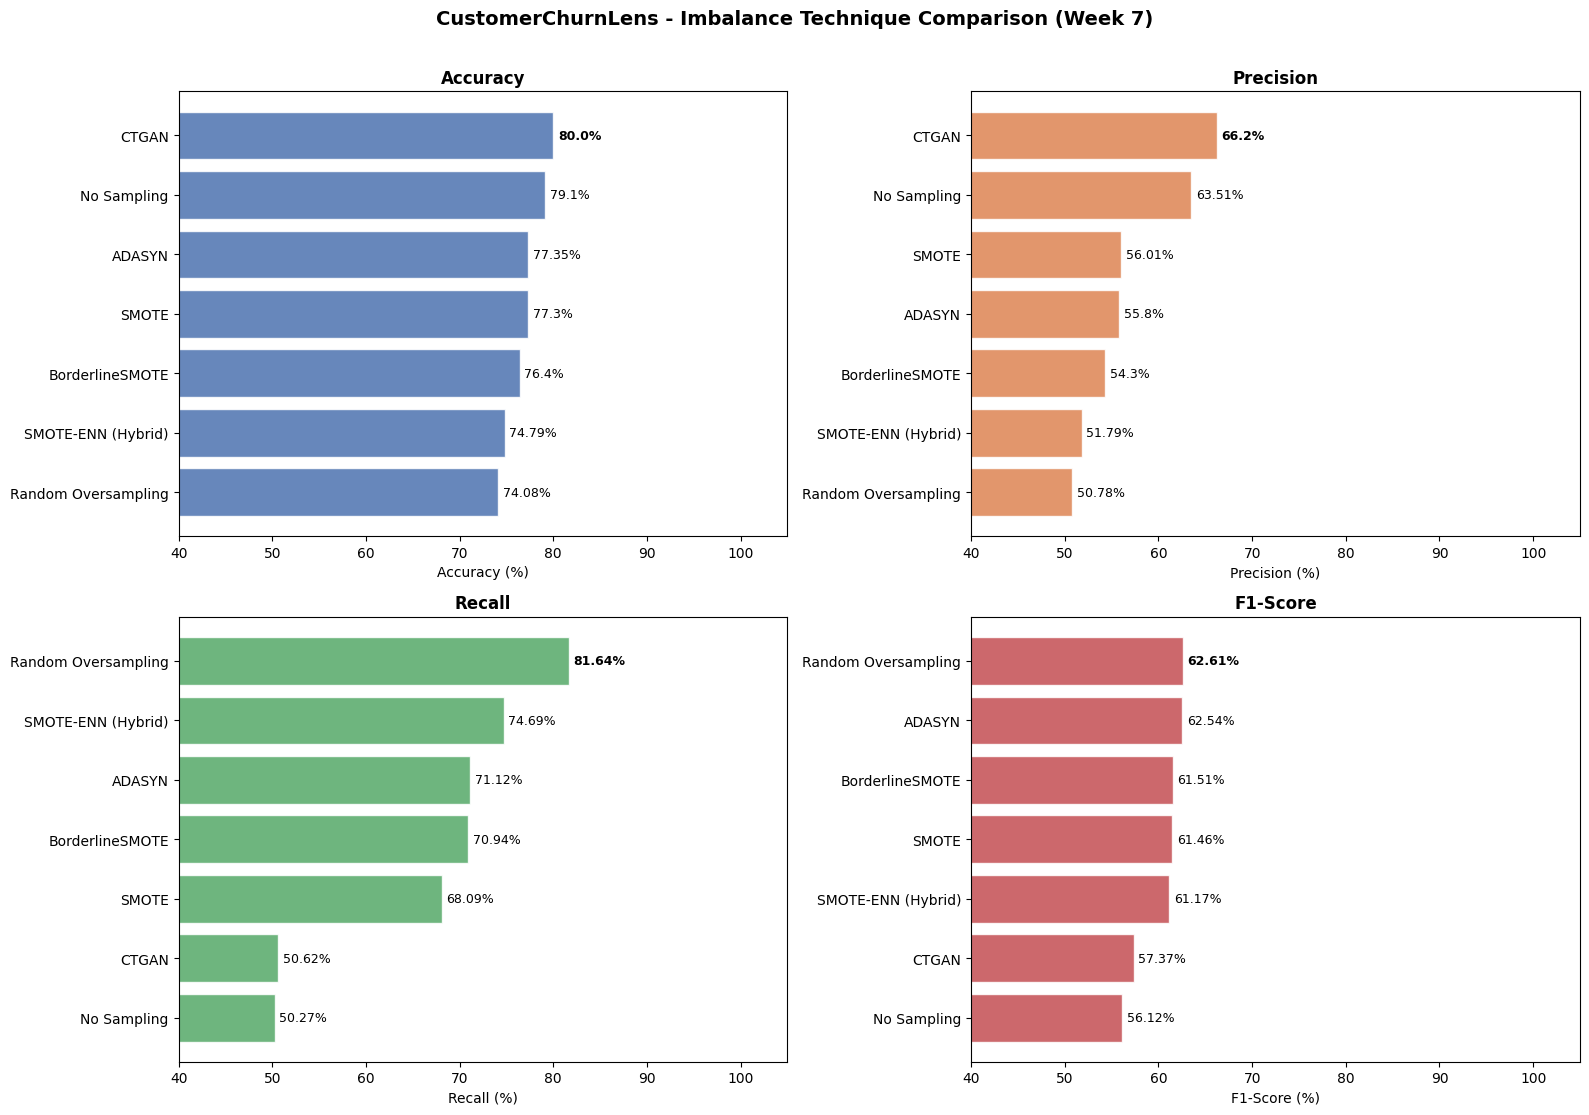

Chart saved as: imbalance_comparison.png


In [ ]:
results_df['Short Name'] = results_df['Method'].str.replace(r'^\d+\.\s*', '', regex=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'CustomerChurnLens - Imbalance Technique Comparison (Week 7)',
    fontsize=14, fontweight='bold', y=1.01
)

metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    sorted_df = results_df.sort_values(metric)

    bars = ax.barh(
        sorted_df['Short Name'],
        sorted_df[metric],
        color=color, alpha=0.85, edgecolor='white'
    )
    ax.set_xlabel(f'{metric}')
    ax.set_title(metric.replace(' (%)', ''), fontweight='bold', fontsize=12)
    ax.set_xlim(40, 105)

    max_val = sorted_df[metric].max()
    for bar, val in zip(bars, sorted_df[metric]):
        bar_color = color if val < max_val else '#2d2d2d'
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val}%',
            va='center', fontsize=9,
            fontweight='bold' if val == max_val else 'normal'
        )

plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as: imbalance_comparison.png')

## Step 11: Recall vs Precision Trade-off Chart

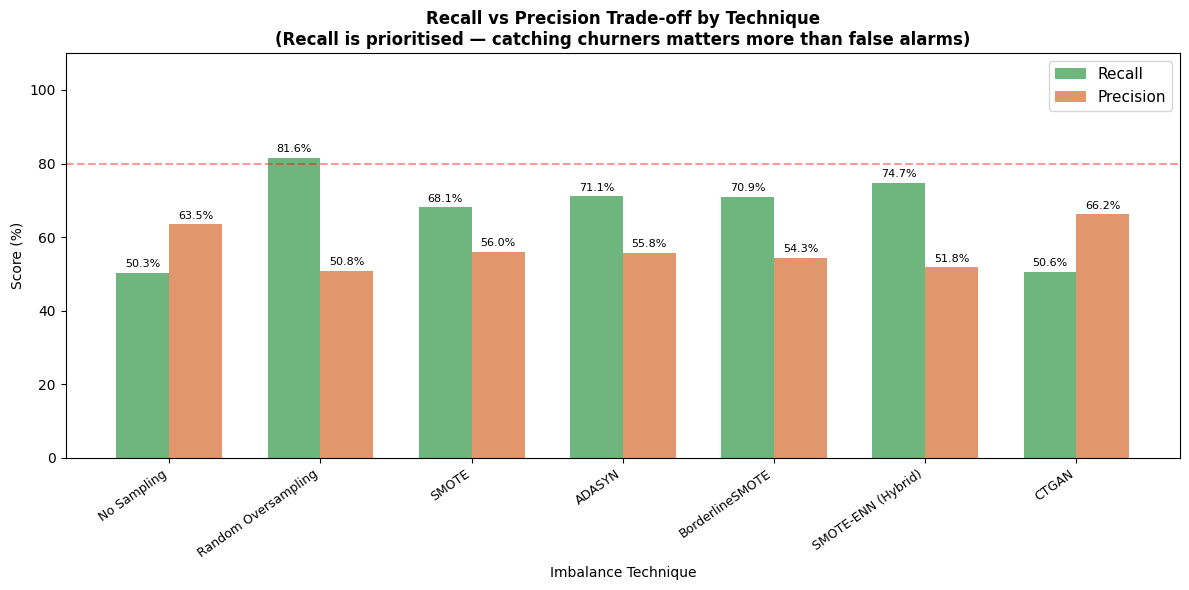

Chart saved as: recall_precision_tradeoff.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Recall (%)'],    width, label='Recall',    color='#55A868', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['Precision (%)'], width, label='Precision', color='#DD8452', alpha=0.85)

ax.set_xlabel('Imbalance Technique')
ax.set_ylabel('Score (%)')
ax.set_title('Recall vs Precision Trade-off by Technique\n(Recall is prioritised — catching churners matters more than false alarms)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Short Name'], rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.4, label='80% target')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('recall_precision_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as: recall_precision_tradeoff.png')

## Step 12: SHAP Explainability
Using best model (XGBoost + SMOTE) to generate SHAP plots.

In [ ]:
import shap

print('Retraining XGBoost + SMOTE for SHAP analysis...')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

best_model = get_xgb_model()
best_model.fit(X_train_smote, y_train_smote)

print('Generating SHAP values...')
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print('Done!')

Retraining XGBoost + SMOTE for SHAP analysis...
Generating SHAP values...
Done!


### SHAP Plot 1: Summary Plot (Dot)
- Features ranked top to bottom by importance
- Each dot = one customer
- Red dot = high feature value, Blue dot = low feature value
- Right of centre = pushes toward churn, Left = pushes away

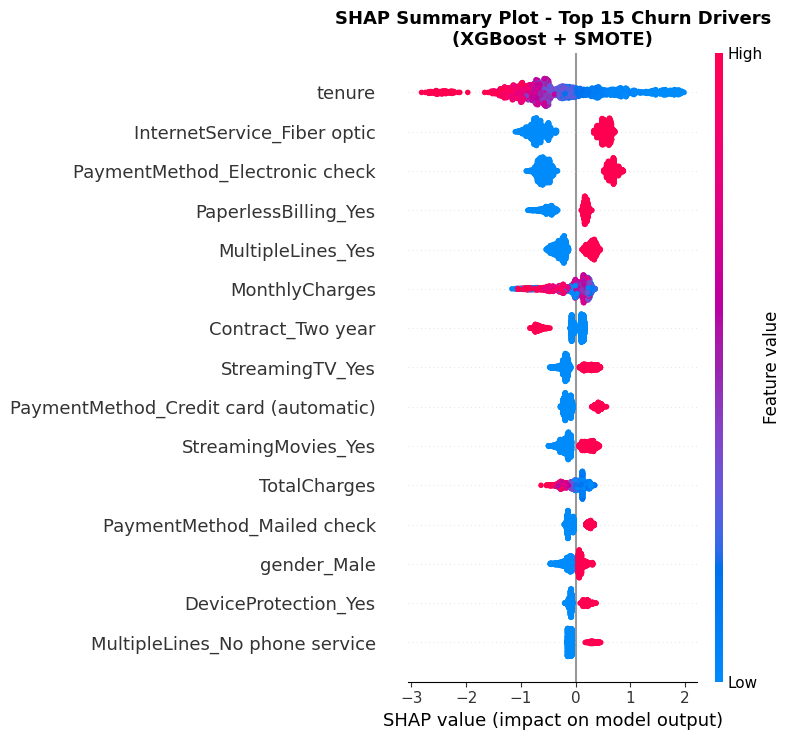

Saved: shap_summary_dot.png


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='dot', max_display=15, show=False)
plt.title('SHAP Summary Plot - Top 15 Churn Drivers\n(XGBoost + SMOTE)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary_dot.png')

### SHAP Plot 2: Summary Plot (Bar)
Simpler version - average impact of each feature across all customers.

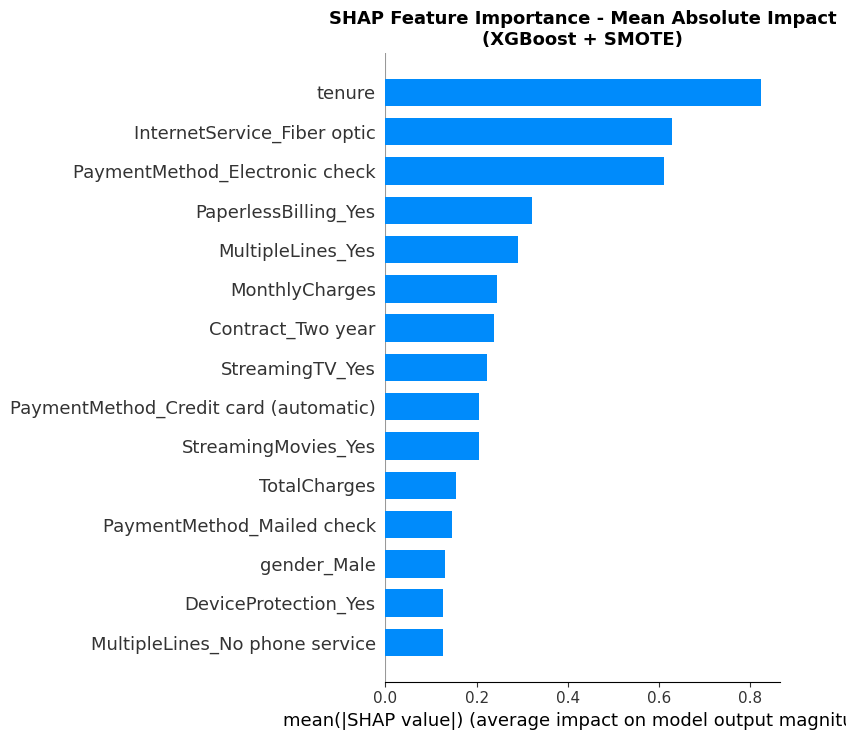

Saved: shap_summary_bar.png


In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance - Mean Absolute Impact\n(XGBoost + SMOTE)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary_bar.png')

### SHAP Plot 3: Waterfall Plot - Individual Customer
WHY a specific high-risk customer was flagged: show the business in a single prediction.

Explaining Customer #1484
Predicted churn probability: 96.9%
Actual outcome: Churned


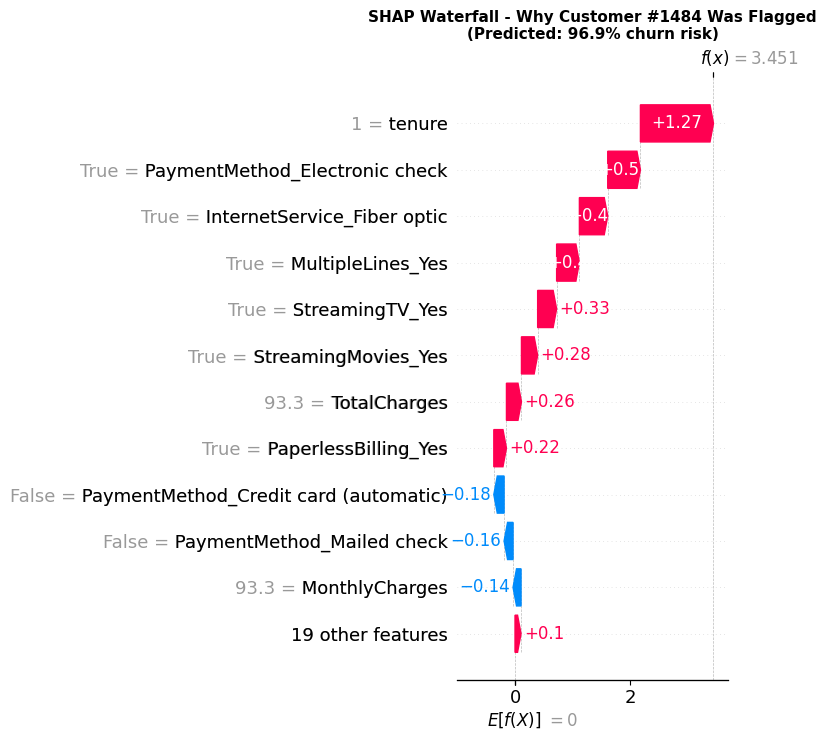

Saved: shap_waterfall.png


In [ ]:
y_pred_proba  = best_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(y_pred_proba)

print(f'Explaining Customer #{high_risk_idx}')
print(f'Predicted churn probability: {y_pred_proba[high_risk_idx]*100:.1f}%')
print(f'Actual outcome: {"Churned" if y_test.iloc[high_risk_idx]==1 else "Stayed"}')

shap_exp = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[high_risk_idx].values,
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(
    f'SHAP Waterfall - Why Customer #{high_risk_idx} Was Flagged\n'
    f'(Predicted: {y_pred_proba[high_risk_idx]*100:.1f}% churn risk)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall.png')

## Step 13: Final Summary

In [ ]:
print('\n--- FULL COMPARISON TABLE ---')
display_cols = ['Method', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
print(results_df[display_cols].to_string(index=False))

print('\n--- IMPROVEMENT OVER BASELINE ---')
baseline_recall = baseline['Recall (%)']
baseline_f1     = baseline['F1-Score (%)']
for _, row in results_df.iterrows():
    if 'Baseline' not in row['Method']:
        recall_gain = round(row['Recall (%)'] - baseline_recall, 2)
        f1_gain     = round(row['F1-Score (%)'] - baseline_f1, 2)
        print(f"  {row['Method']}: Recall {'+' if recall_gain>=0 else ''}{recall_gain}% | "
              f"F1 {'+' if f1_gain>=0 else ''}{f1_gain}%")


--- FULL COMPARISON TABLE ---
                Method  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
        1. No Sampling         79.10          63.51       50.27         56.12
2. Random Oversampling         74.08          50.78       81.64         62.61
              3. SMOTE         77.30          56.01       68.09         61.46
             4. ADASYN         77.35          55.80       71.12         62.54
    5. BorderlineSMOTE         76.40          54.30       70.94         61.51
 7. SMOTE-ENN (Hybrid)         74.79          51.79       74.69         61.17
              8. CTGAN         80.00          66.20       50.62         57.37

--- IMPROVEMENT OVER BASELINE ---
  1. No Sampling: Recall +0.0% | F1 +0.0%
  2. Random Oversampling: Recall +31.37% | F1 +6.49%
  3. SMOTE: Recall +17.82% | F1 +5.34%
  4. ADASYN: Recall +20.85% | F1 +6.42%
  5. BorderlineSMOTE: Recall +20.67% | F1 +5.39%
  7. SMOTE-ENN (Hybrid): Recall +24.42% | F1 +5.05%
  8. CTGAN: Recall +0.35% | F1 +1.2